In [3]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

import os

In [4]:
load_dotenv()
OPEN_ROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")

In [5]:
llm = ChatOpenAI(
    api_key=OPEN_ROUTER_API_KEY,
    base_url= "https://openrouter.ai/api/v1",
    model = "openai/gpt-4o-mini"
)

In [6]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [7]:
def create_outline(state: BlogState) -> BlogState:
    title = state['title']

    prompt = f"Create an outline for a blog post with the title: {title}"

    outline = llm.invoke(prompt).content

    state['outline'] = outline

    return state

In [8]:
def create_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']

    prompt = f"Write a blog post with the title: {title} and the following outline: {outline}"

    content = llm.invoke(prompt).content

    state['content'] = content

    return state

In [9]:
graph = StateGraph(BlogState)

graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

In [10]:
initial_state = {'title': "Beginner friendly workouts for V-shaped body"}

final_state = workflow.invoke(initial_state)
print(final_state)  

{'title': 'Beginner friendly workouts for V-shaped body', 'outline': '### Blog Post Outline: Beginner Friendly Workouts for a V-Shaped Body\n\n#### Introduction\n- Brief explanation of the V-shaped body type and its characteristics.\n- Importance of a well-rounded workout routine for achieving a V-shape.\n- Overview of the post and what readers can expect to learn.\n\n#### Section 1: Understanding the V-Shaped Physique\n- Definition of the V-shaped body (broad shoulders and a narrow waist).\n- Benefits of having a V-shaped body (aesthetic appeal, balanced strength).\n- Overview of the muscle groups to focus on for a V-shape: shoulders, back, and core.\n\n#### Section 2: Essential Elements of Beginner Workouts\n- Importance of starting with foundational exercises.\n- Tips for maintaining proper form and avoiding injury.\n- The significance of consistency and progression in strength training.\n\n#### Section 3: Warm-Up Routine\n- Importance of warming up before workouts.\n- Suggested war

In [13]:
print(final_state['outline'])

### Blog Post Outline: Beginner Friendly Workouts for a V-Shaped Body

#### Introduction
- Brief explanation of the V-shaped body type and its characteristics.
- Importance of a well-rounded workout routine for achieving a V-shape.
- Overview of the post and what readers can expect to learn.

#### Section 1: Understanding the V-Shaped Physique
- Definition of the V-shaped body (broad shoulders and a narrow waist).
- Benefits of having a V-shaped body (aesthetic appeal, balanced strength).
- Overview of the muscle groups to focus on for a V-shape: shoulders, back, and core.

#### Section 2: Essential Elements of Beginner Workouts
- Importance of starting with foundational exercises.
- Tips for maintaining proper form and avoiding injury.
- The significance of consistency and progression in strength training.

#### Section 3: Warm-Up Routine
- Importance of warming up before workouts.
- Suggested warm-up exercises:
  - Arm circles
  - Shoulder stretches
  - Dynamic leg swings
  - Cat-Cow

In [12]:
print(final_state['content'])

# Beginner Friendly Workouts for a V-Shaped Body

## Introduction
The V-shaped body is characterized by broad shoulders tapering to a narrow waist, creating an aesthetically pleasing silhouette often associated with strength and athleticism. This body type is sought after not just for its appearance but also for the functional balance it provides. However, achieving a V-shape is not simply about aesthetics; it requires a well-rounded workout routine that builds both strength and endurance in the right areas. In this post, we will explore what a V-shaped physique entails, key exercises to help you achieve this look, and how to develop a consistent workout plan suited for beginners.

## Section 1: Understanding the V-Shaped Physique
A V-shaped body features well-defined shoulders and a slim waist, evoking a strong, confident presence. This body type comes with numerous benefits, including improved posture and balanced strength, which are essential for various physical activities. To work

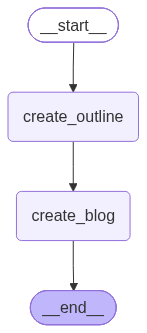

In [11]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())